In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.image as mpimg
import matplotlib.patches as patches
import matplotlib as mpl
from mplsoccer import Pitch, VerticalPitch, FontManager, Sbopen, add_image
from matplotlib.font_manager import FontProperties
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.patheffects as path_effects
from highlight_text import ax_text, fig_text
from PIL import Image
from mplsoccer import add_image
from urllib.request import urlopen
import os


# Print the modified DataFrame
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

green = '#69f900'
red = '#ff4b44'
blue = '#00a0de'
violet = '#a369ff'
bg_color= '#f5f5f5'
line_color= '#000000'
col1 = '#ff4b44'
col2 = '#00a0de'

# # UCL
# col1 = '#f659fd'
# col2 = '#33efff'
# bg_color = '#060F38'
# line_color = '#ffffff'
# green = '#69f900'
# red = '#ff4b44'

In [8]:
dfl = pd.read_csv(r"D:\Statsbomb\La Liga 2024_25\Merged\La_Liga_2024_2025_till_gw38.csv")

In [3]:
dfe = pd.read_csv(r"D:\Statsbomb\Premier League 2024_25\merged\Premier_League_2024_25_till_gw38.csv")

C:\Users\h\AppData\Local\Temp\ipykernel_19280\3686424881.py:1: DtypeWarning: Columns (48) have mixed types. Specify dtype option on import or set low_memory=False.
  dfe = pd.read_csv(r"D:\Statsbomb\Premier League 2024_25\merged\Premier_League_2024_25_till_gw38.csv")


In [2]:
dfs = pd.read_csv(r"D:\Statsbomb\Serie A 2024_25\Merged\Serie_A_till_GW38.csv")

In [25]:
# Drop one of the duplicate columns (e.g., 'name_y')
dfs.drop('player_known_name_y', axis=1, inplace=True)

# Rename the remaining column ('player_known_name_x') to 'name'
dfs.rename(columns={'player_known_name_x': 'player_known_name'}, inplace=True)

In [26]:
dfs.to_csv(r"D:\Statsbomb\Serie A 2024_25\Merged\Serie_A_till_GW38.csv")

In [3]:
def calculation(df, pname):
    pitch = VerticalPitch(half=True, corner_arcs=True, goal_type='box')
    
    dims = pitch.dim

    goal_line = dims.length
    left_zone_x_start = dims.penalty_area_top
    left_zone_x_end = (dims.goal_top + (dims.goal_width)/3)
    right_zone_x_end = dims.penalty_area_bottom
    right_zone_x_start = (dims.goal_bottom - (dims.goal_width)/3)
    left_near_post_x_start = (dims.goal_top - (dims.goal_width)/3)
    left_near_post_x_end = (dims.goal_top + (dims.goal_width)/3)
    right_near_post_x_start = (dims.goal_bottom - (dims.goal_width)/3)
    right_near_post_x_end = (dims.goal_bottom + (dims.goal_width)/3)
    # near post shots
    # right zone
    l_np_shots = df[(df['player_known_name']==pname) & (df['event_type_name']=='Shot') & (df['outcome_name']!='Blocked') & 
                    (df['type_name']=='Open Play') & (df['body_part_name']!='Head') & (df['body_part_name']!='Other') &
                    (df['location_y']>left_zone_x_start) & (df['location_y']<left_zone_x_end) &
                    (df['end_location_y']>left_near_post_x_start) & (df['end_location_y']<left_near_post_x_end) & 
                    (df['end_location_x']>117) & (df['location_x']>80)].drop_duplicates(subset=['id'], keep='first')

    # left zone
    r_np_shots = df[(df['player_known_name']==pname) & (df['event_type_name']=='Shot') & (df['outcome_name']!='Blocked') & 
                    (df['type_name']=='Open Play') & (df['body_part_name']!='Head') & (df['body_part_name']!='Other') &
                    (df['location_y']>right_zone_x_start) & (df['location_y']<right_zone_x_end) &
                    (df['end_location_y']>right_near_post_x_start) & (df['end_location_y']<right_near_post_x_end) & 
                    (df['end_location_x']>117) & (df['location_x']>80)].drop_duplicates(subset=['id'], keep='first')

    # far post shots
    # right zone
    l_fp_shots = df[(df['player_known_name']==pname) & (df['event_type_name']=='Shot') & (df['outcome_name']!='Blocked') & 
                    (df['type_name']=='Open Play') & (df['body_part_name']!='Head') & (df['body_part_name']!='Other') &
                    (df['location_y']>left_zone_x_start) & (df['location_y']<left_zone_x_end) &
                    (df['end_location_y']>right_near_post_x_start) & (df['end_location_y']<right_near_post_x_end) & 
                    (df['end_location_x']>117) & (df['location_x']>80)].drop_duplicates(subset=['id'], keep='first')

    # left zone
    r_fp_shots = df[(df['player_known_name']==pname) & (df['event_type_name']=='Shot') & (df['outcome_name']!='Blocked') & 
                    (df['type_name']=='Open Play') & (df['body_part_name']!='Head') & (df['body_part_name']!='Other') &
                    (df['location_y']>right_zone_x_start) & (df['location_y']<right_zone_x_end) &
                    (df['end_location_y']>left_near_post_x_start) & (df['end_location_y']<left_near_post_x_end) & 
                    (df['end_location_x']>117) & (df['location_x']>80)].drop_duplicates(subset=['id'], keep='first')

    total_np = len(l_np_shots) + len(r_np_shots)
    total_fp = len(l_fp_shots) + len(r_fp_shots)
    
    return total_np, total_fp

def near_post(df, ax, pname):
    pitch = VerticalPitch(half=True, corner_arcs=True, goal_type='box')
    pitch.draw(ax=ax)
    
    dims = pitch.dim

    goal_line = dims.length
    left_zone_x_start = dims.penalty_area_top
    left_zone_x_end = (dims.goal_top + (dims.goal_width)/3)
    right_zone_x_end = dims.penalty_area_bottom
    right_zone_x_start = (dims.goal_bottom - (dims.goal_width)/3)
    left_near_post_x_start = (dims.goal_top - (dims.goal_width)/3)
    left_near_post_x_end = (dims.goal_top + (dims.goal_width)/3)
    right_near_post_x_start = (dims.goal_bottom - (dims.goal_width)/3)
    right_near_post_x_end = (dims.goal_bottom + (dims.goal_width)/3)
    
    # light fills
    ax.fill_between([left_zone_x_start, left_zone_x_end], goal_line, (goal_line)*2/3, color=col1, alpha=0.25, zorder=10, ls='dashed', lw=2)
    ax.fill_between([right_zone_x_start, right_zone_x_end], goal_line, (goal_line)*2/3, color=col2, alpha=0.25, zorder=10, ls='dashed', lw=2)
    
    # edge fills
    ax.fill_between([left_zone_x_start, left_zone_x_end], goal_line, (goal_line)*2/3, color='None', alpha=1, zorder=10, ls='dashed', lw=2,  ec=col1)
    ax.fill_between([right_zone_x_start, right_zone_x_end], goal_line, (goal_line)*2/3, color='None', alpha=1, zorder=10, ls='dashed', lw=2,  ec=col2)
    
    # near/far post lines
    ax.hlines(y=goal_line, xmin=left_near_post_x_start, xmax=left_near_post_x_end, color=col1, linestyle='-', linewidth=7.5, zorder=11)
    ax.hlines(y=goal_line, xmin=right_near_post_x_start, xmax=right_near_post_x_end, color=col2, linestyle='-', linewidth=7.5, zorder=11)

    # near post shots
    # right zone
    l_np_shots = df[(df['player_known_name']==pname) & (df['event_type_name']=='Shot') & (df['outcome_name']!='Blocked') & 
                    (df['type_name']=='Open Play') & (df['body_part_name']!='Head') & (df['body_part_name']!='Other') &
                    (df['location_y']>left_zone_x_start) & (df['location_y']<left_zone_x_end) &
                    (df['end_location_y']>left_near_post_x_start) & (df['end_location_y']<left_near_post_x_end) & 
                    (df['end_location_x']>117) & (df['location_x']>80)].drop_duplicates(subset=['id'], keep='first')

    ax.scatter(l_np_shots.location_y, l_np_shots.location_x, s=50+(l_np_shots.statsbomb_xg)*500, color='w', edgecolor='k', zorder=3)
    pitch.lines(l_np_shots.end_location_x, l_np_shots.end_location_y, l_np_shots.location_x, l_np_shots.location_y, comet=True, transparent=True,
                color='gray', alpha=0.25, lw=2.5, zorder=2, ax=ax)

    # left zone
    r_np_shots = df[(df['player_known_name']==pname) & (df['event_type_name']=='Shot') & (df['outcome_name']!='Blocked') & 
                    (df['type_name']=='Open Play') & (df['body_part_name']!='Head') & (df['body_part_name']!='Other') &
                    (df['location_y']>right_zone_x_start) & (df['location_y']<right_zone_x_end) &
                    (df['end_location_y']>right_near_post_x_start) & (df['end_location_y']<right_near_post_x_end) & 
                    (df['end_location_x']>117) & (df['location_x']>80)].drop_duplicates(subset=['id'], keep='first')

    ax.scatter(r_np_shots.location_y, r_np_shots.location_x, s=50+(r_np_shots.statsbomb_xg)*500, color='w', edgecolor='k', zorder=3)
    pitch.lines(r_np_shots.end_location_x, r_np_shots.end_location_y, r_np_shots.location_x, r_np_shots.location_y, comet=True, transparent=True,
                color='k', alpha=0.25, lw=2.5, zorder=2, ax=ax)

    np_shots = pd.concat([l_np_shots, r_np_shots])
    goals = np_shots[np_shots['outcome_name']=='Goal']
    ax.scatter(goals.location_y, goals.location_x, s=50+(goals.statsbomb_xg)*500, color='green', edgecolor='k', zorder=4)
    
    ax.set_title(f'Near Post ({np_pc}% Shots)', fontsize=20, fontweight='bold')
    left_xg = l_np_shots['statsbomb_xg'].sum()
    right_xg = r_np_shots['statsbomb_xg'].sum()
    ax.text(left_zone_x_start, (goal_line*2/3) - 5, f"Left Zone\n{len(l_np_shots)} Shots ({left_xg:.2f} xG)", color=col1, fontsize=20, ha='center', va='center')
    ax.text(right_zone_x_end, (goal_line*2/3) - 5, f"Right Zone\n{len(r_np_shots)} Shots ({right_xg:.2f} xG)", color=col2, fontsize=20, ha='center', va='center')

    ax.text(40, 65, f'{len(goals)} Goals\nfrom {(left_xg+right_xg):.2f} xG', color='green', fontsize=20, ha='center', va='center')
    
    return

def far_post(df, ax, pname):
    pitch = VerticalPitch(half=True, corner_arcs=True, goal_type='box')
    pitch.draw(ax=ax)
    
    dims = pitch.dim

    goal_line = dims.length
    left_zone_x_start = dims.penalty_area_top
    left_zone_x_end = (dims.goal_top + (dims.goal_width)/3)
    right_zone_x_end = dims.penalty_area_bottom
    right_zone_x_start = (dims.goal_bottom - (dims.goal_width)/3)
    left_near_post_x_start = (dims.goal_top - (dims.goal_width)/3)
    left_near_post_x_end = (dims.goal_top + (dims.goal_width)/3)
    right_near_post_x_start = (dims.goal_bottom - (dims.goal_width)/3)
    right_near_post_x_end = (dims.goal_bottom + (dims.goal_width)/3)
    
    # light fills
    ax.fill_between([left_zone_x_start, left_zone_x_end], goal_line, (goal_line)*2/3, color=col1, alpha=0.25, zorder=10, ls='dashed', lw=2)
    ax.fill_between([right_zone_x_start, right_zone_x_end], goal_line, (goal_line)*2/3, color=col2, alpha=0.25, zorder=10, ls='dashed', lw=2)
    
    # edge fills
    ax.fill_between([left_zone_x_start, left_zone_x_end], goal_line, (goal_line)*2/3, color='None', alpha=1, zorder=10, ls='dashed', lw=2,  ec=col1)
    ax.fill_between([right_zone_x_start, right_zone_x_end], goal_line, (goal_line)*2/3, color='None', alpha=1, zorder=10, ls='dashed', lw=2,  ec=col2)
    
    # near/far post lines
    ax.hlines(y=goal_line, xmin=left_near_post_x_start, xmax=left_near_post_x_end, color=col1, linestyle='-', linewidth=7.5, zorder=11)
    ax.hlines(y=goal_line, xmin=right_near_post_x_start, xmax=right_near_post_x_end, color=col2, linestyle='-', linewidth=7.5, zorder=11)

    # far post shots
    # right zone
    l_fp_shots = df[(df['player_known_name']==pname) & (df['event_type_name']=='Shot') & (df['outcome_name']!='Blocked') & 
                    (df['type_name']=='Open Play') & (df['body_part_name']!='Head') & (df['body_part_name']!='Other') &
                    (df['location_y']>left_zone_x_start) & (df['location_y']<left_zone_x_end) &
                    (df['end_location_y']>right_near_post_x_start) & (df['end_location_y']<right_near_post_x_end) & 
                    (df['end_location_x']>117) & (df['location_x']>80)].drop_duplicates(subset=['id'], keep='first')

    ax.scatter(l_fp_shots.location_y, l_fp_shots.location_x, s=50+(l_fp_shots.statsbomb_xg)*500, color='w', edgecolor='k', zorder=3)
    pitch.lines(l_fp_shots.end_location_x, l_fp_shots.end_location_y, l_fp_shots.location_x, l_fp_shots.location_y, comet=True, transparent=True,
                color='gray', alpha=0.25, lw=2.5, zorder=2, ax=ax)

    # left zone
    r_fp_shots = df[(df['player_known_name']==pname) & (df['event_type_name']=='Shot') & (df['outcome_name']!='Blocked') & 
                    (df['type_name']=='Open Play') & (df['body_part_name']!='Head') & (df['body_part_name']!='Other') &
                    (df['location_y']>right_zone_x_start) & (df['location_y']<right_zone_x_end) &
                    (df['end_location_y']>left_near_post_x_start) & (df['end_location_y']<left_near_post_x_end) & 
                    (df['end_location_x']>117) & (df['location_x']>80)].drop_duplicates(subset=['id'], keep='first')

    ax.scatter(r_fp_shots.location_y, r_fp_shots.location_x, s=50+(r_fp_shots.statsbomb_xg)*500, color='w', edgecolor='k', zorder=3)
    pitch.lines(r_fp_shots.end_location_x, r_fp_shots.end_location_y, r_fp_shots.location_x, r_fp_shots.location_y, comet=True, transparent=True,
                color='k', alpha=0.25, lw=2.5, zorder=2, ax=ax)

    fp_shots = pd.concat([l_fp_shots, r_fp_shots])
    goals = fp_shots[fp_shots['outcome_name']=='Goal']
    ax.scatter(goals.location_y, goals.location_x, s=50+(goals.statsbomb_xg)*500, color='green', edgecolor='k', zorder=4)
    
    ax.set_title(f'Far Post ({fp_pc}% Shots)', fontsize=20, fontweight='bold')
    left_xg = l_fp_shots['statsbomb_xg'].sum()
    right_xg = r_fp_shots['statsbomb_xg'].sum()
    ax.text(left_zone_x_start, (goal_line*2/3) - 5, f"Left Zone\n{len(l_fp_shots)} Shots ({left_xg:.2f} xG)", color=col1, fontsize=20, ha='center', va='center')
    ax.text(right_zone_x_end, (goal_line*2/3) - 5, f"Right Zone\n{len(r_fp_shots)} Shots ({right_xg:.2f} xG)", color=col2, fontsize=20, ha='center', va='center')

    ax.text(40, 65, f'{len(goals)} Goals\nfrom {(left_xg+right_xg):.2f} xG', color='green', fontsize=20, ha='center', va='center')

    return

In [9]:
sorted(dfl[dfl['player_position_name'].isin(['Left Wing', 'Right Wing', 
                                      'Left Center Forward', 'Center Forward', 'Right Center Forward'
                                     ])].player_known_name.fillna('').unique())

['Abde Ezzalzouli',
 'Abderrahman Rebbach',
 'Abdón Prats',
 'Abel Bretones Cruz',
 'Abel Ruiz',
 'Adam Aznou',
 'Adama Boiro Boiro',
 'Adnan Januzaj',
 'Adri Embarba',
 'Adrià Altimira',
 'Adrián Arnuncio',
 'Adrián Niño Heredia',
 'Aimar Oroz',
 'Aingeru Olabarrieta',
 'Aitor Ruibal',
 'Akor Jerome Adams',
 'Alberto Mari',
 'Alberto Moleiro',
 'Alberto Risco Alcántara',
 'Alejandro Balde',
 'Alejo Véliz',
 'Alex Král',
 'Alexander Sørloth',
 'Alfon González',
 'Alfonso Espino',
 'Allan Nyom',
 'Alvaro Pascual',
 'Amath Ndiaye',
 'Anastasios Douvikas',
 'Ander Barrenetxea',
 'Andrei Ratiu',
 'André Almeida',
 'Ansu Fati',
 'Ante Budimir',
 'Antoine Griezmann',
 'Antonio Blanco',
 'Antonio Sánchez',
 'Antoniu Roca',
 'Antony',
 'Anuar Tuhami',
 'Arda Güler',
 'Arkaitz Mariezkurrena',
 'Arnau Martinez',
 'Arnau Solà',
 'Arnaut Danjuma',
 'Arsen Zakharyan',
 'Arthur',
 'Arturo Rodríguez',
 'Asier Villalibre',
 'Assane Diao',
 'Ayoze Pérez',
 'Benito Ramírez',
 'Bertuğ Özgür Yıldırım',
 '

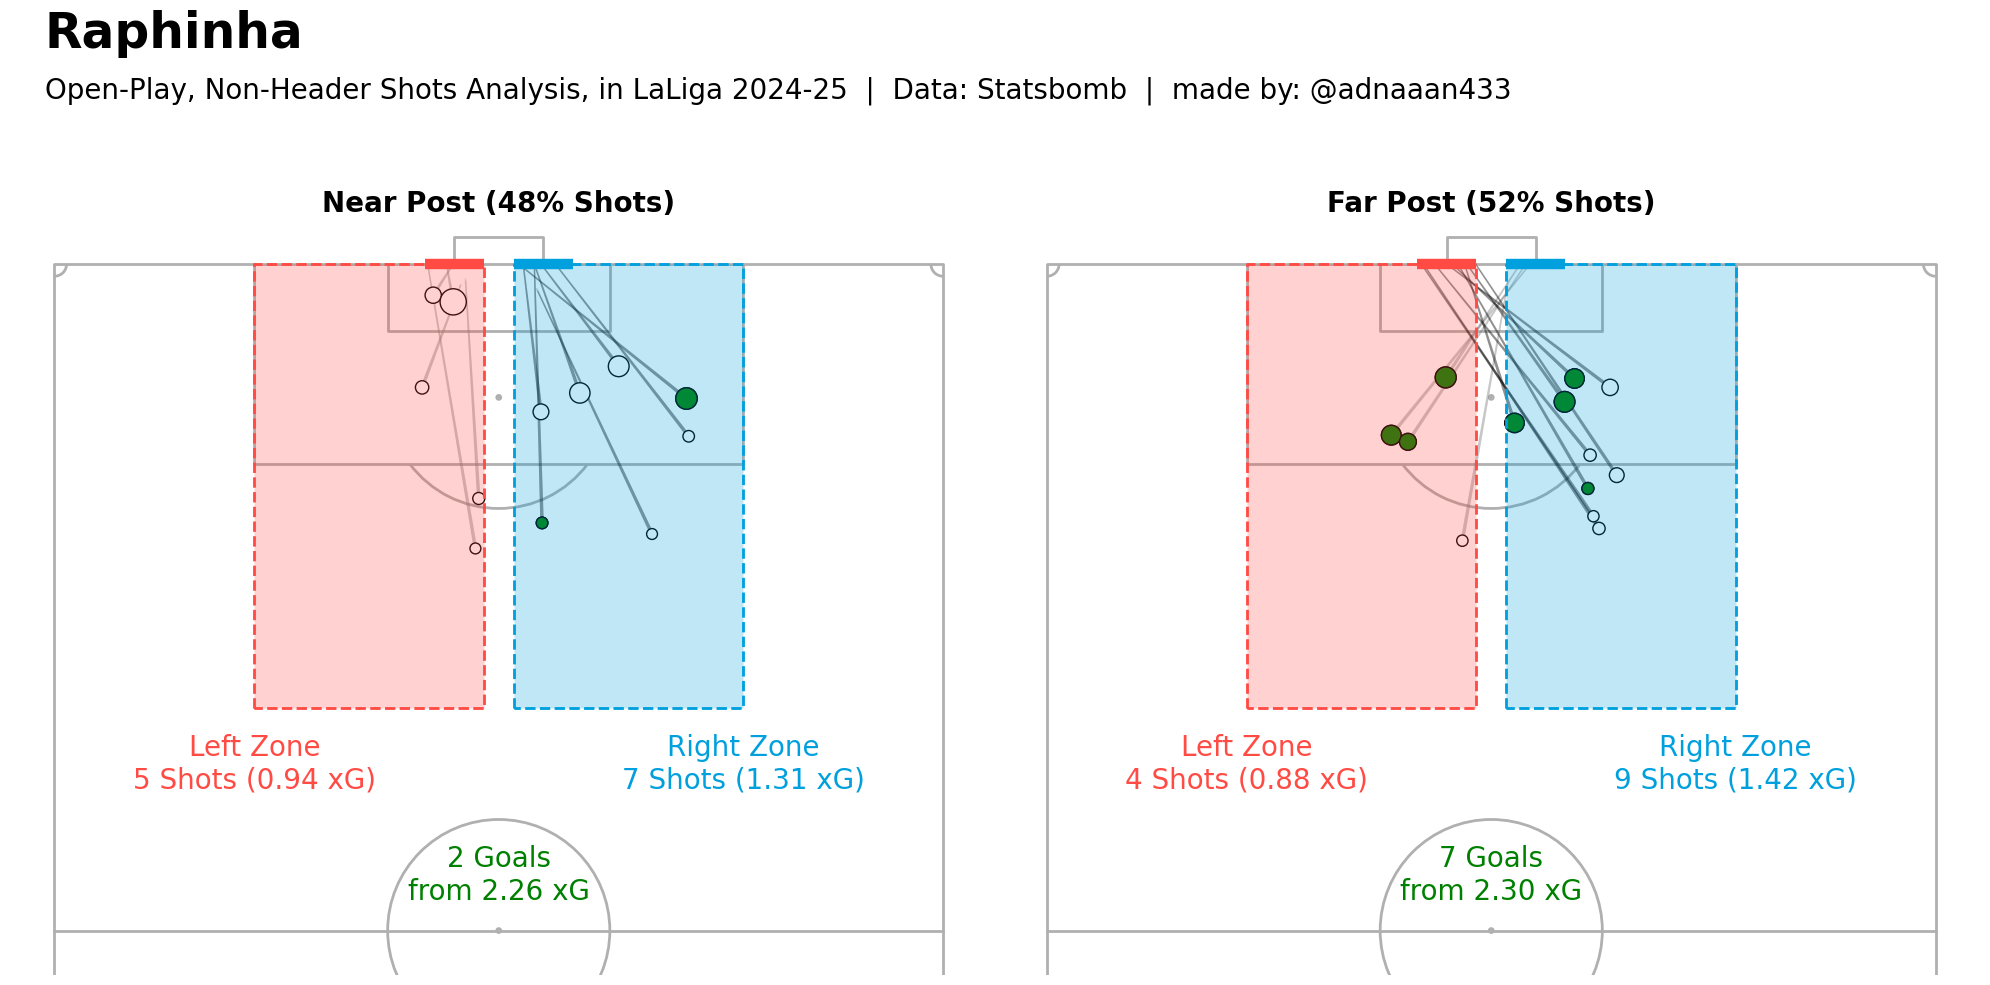

In [20]:
pname = 'Raphinha'
df = dfl
total_np, total_fp = calculation(df, pname)
np_pc = round((total_np/(total_np+total_fp))*100)
fp_pc = round((total_fp/(total_np+total_fp))*100)
fig, axs = plt.subplots(1,2, figsize=(20,10))
near_post(df, axs[0], pname)
far_post(df, axs[1], pname)

fig.text(0.025, 1.05, pname, fontsize=35, fontweight='bold')
fig.text(0.025, 1, 'Open-Play, Non-Header Shots Analysis, in LaLiga 2024-25  |  Data: Statsbomb  |  made by: @adnaaan433', fontsize=20)
# fig.text(0.025, 1.02, '', fontsize=20)

plt.tight_layout()

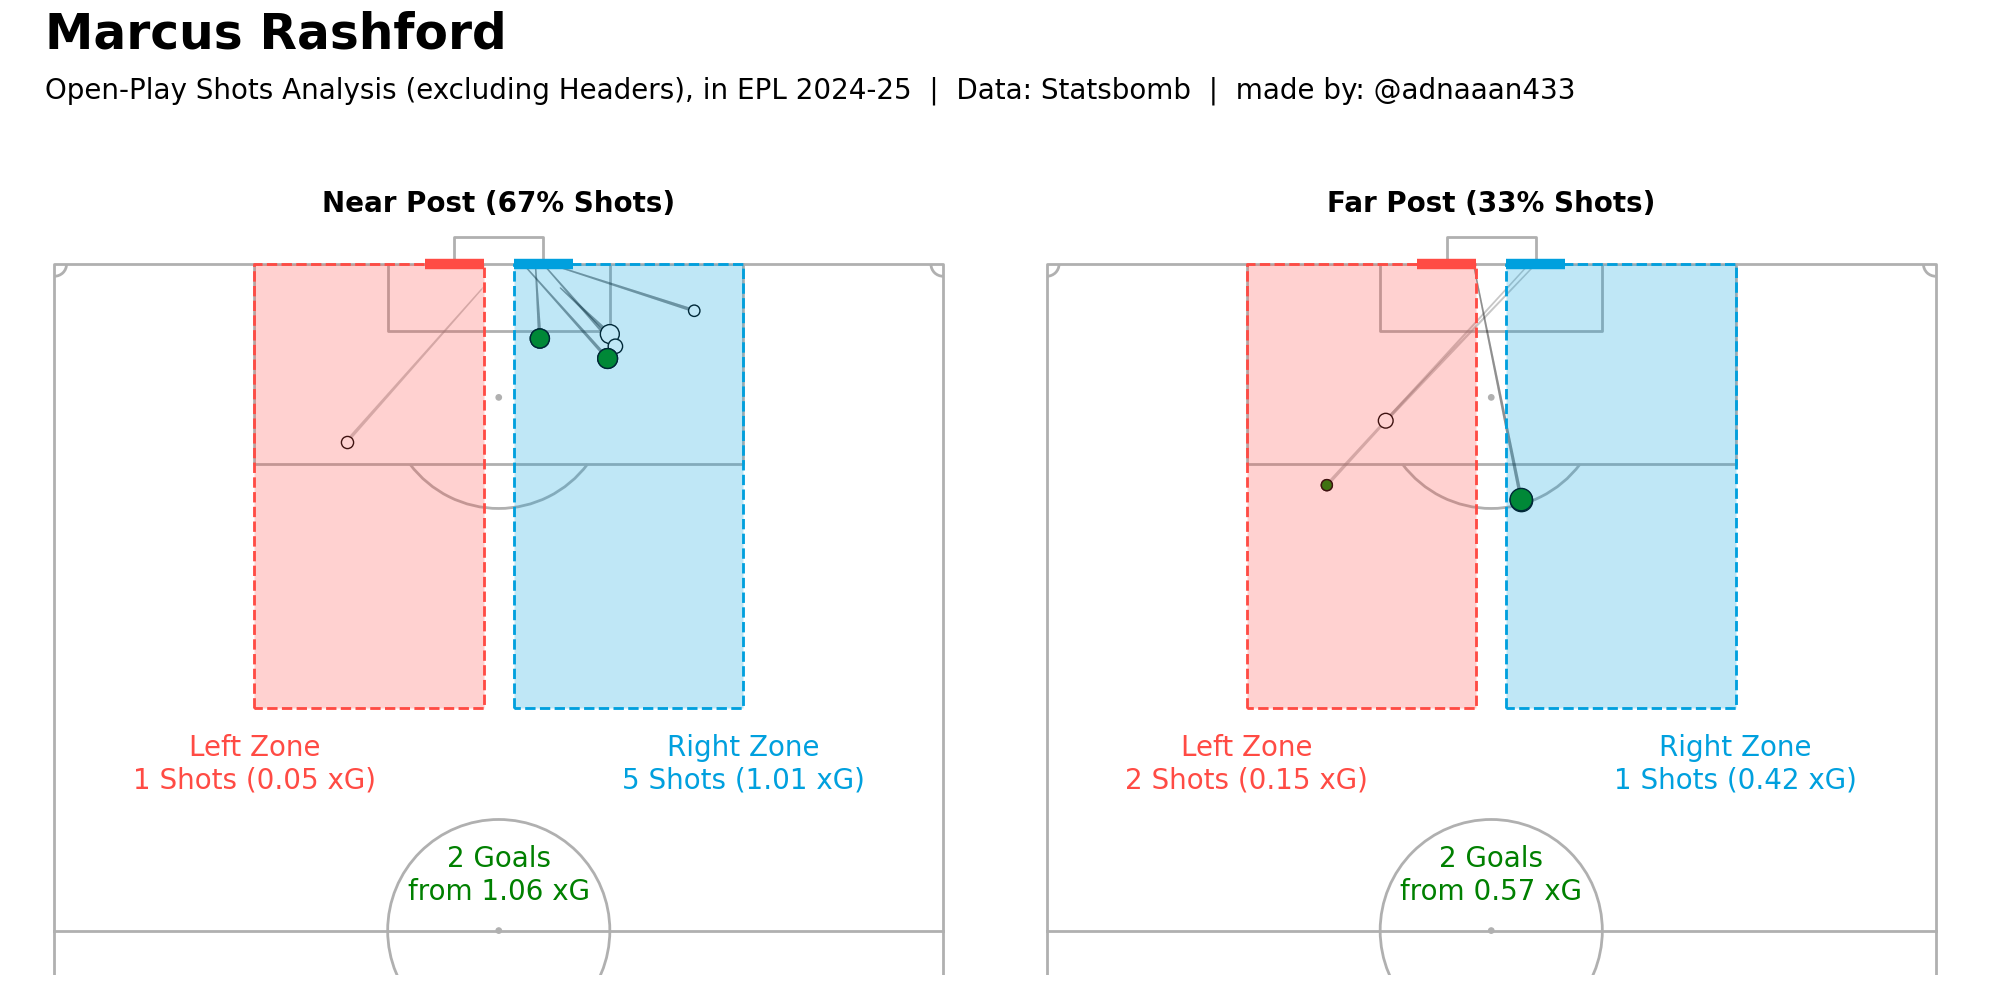

In [19]:
pname = 'Marcus Rashford'
df = dfe
total_np, total_fp = calculation(df, pname)
np_pc = round((total_np/(total_np+total_fp))*100)
fp_pc = round((total_fp/(total_np+total_fp))*100)
fig, axs = plt.subplots(1,2, figsize=(20,10))
near_post(df, axs[0], pname)
far_post(df, axs[1], pname)

fig.text(0.025, 1.05, pname, fontsize=35, fontweight='bold')
fig.text(0.025, 1, 'Open-Play Shots Analysis (excluding Headers), in EPL 2024-25  |  Data: Statsbomb  |  made by: @adnaaan433', fontsize=20)
# fig.text(0.025, 1.02, '', fontsize=20)

plt.tight_layout()

In [54]:
sorted(dfe[dfe['player_position_name'].isin(['Left Wing', 'Right Wing', 
                                      'Left Center Forward', 'Center Forward', 'Right Center Forward'
                                     ])].player_known_name.fillna('').unique())

['Abdoulaye Doucouré',
 'Abdul Fatawu',
 'Adam Armstrong',
 'Adam Lallana',
 'Adam Webster',
 'Adama Traoré',
 'Albert Grønbæk Erlykke',
 'Alejandro Garnacho',
 'Alex Iwobi',
 'Alex Scott',
 'Alexander Isak',
 'Alexis MacAllister',
 'Ali Al-Hamadi',
 'Amad Diallo',
 'Andreas Pereira',
 'Anthony Elanga',
 'Anthony Gordon',
 'Antoine Semenyo',
 'Antony',
 'Armando Broja',
 'Ashley Young',
 'Ben Brereton Díaz',
 'Ben Johnson',
 'Bernardo Silva',
 'Beto',
 'Bilal El Khannous',
 'Bobby De Cordova-Reid',
 'Boubakary Soumaré',
 'Brajan Gruda',
 'Brennan Johnson',
 'Bruno Fernandes',
 'Bruno Guimarães',
 'Bryan Mbeumo',
 'Bukayo Saka',
 'Callum Hudson-Odoi',
 'Callum Wilson',
 'Cameron Archer',
 'Carlos Alcaraz',
 'Carlos Borges',
 'Carlos Soler',
 'Carlos Vinícius',
 'Chidozie Obi-Martin',
 'Chiedozie Ogbene',
 'Chris Wood',
 'Christian Eriksen',
 'Christopher Nkunku',
 'Claudio Echeverri',
 'Cody Gakpo',
 'Cole Palmer',
 'Conor Bradley',
 'Conor Chaplin',
 'Crysencio Summerville',
 'Curtis J

In [4]:
sorted(dfs[dfs['player_position_name'].isin(['Left Wing', 'Right Wing', 
                                      'Left Center Forward', 'Center Forward', 'Right Center Forward'
                                     ])].player_known_name.fillna('').unique())

['Aarón Martín',
 'Abdoulrahmane Harroui',
 'Adam Marušić',
 'Adam Obert',
 'Ademola Lookman',
 'Adrian Benedyczak',
 'Adrien Tameze',
 'Albert Gudmundsson',
 'Alberto Cerri',
 'Alberto Moreno',
 'Alejandro Jiménez',
 'Alessandro Gabrielloni',
 'Alessandro Zanoli',
 'Alessio Iovine',
 'Alessio Romagnoli',
 'Alessio Zerbin',
 'Alexis Saelemaekers',
 'Alexis Sánchez',
 'Ali Al Tameemi',
 'Alieu Eybi Njie',
 'Alieu Fadera',
 'Amin Sarr',
 'Amir Richardson',
 'Anastasios Douvikas',
 'Andrea Belotti',
 'Andrea Cambiaso',
 'Andrea Colpani',
 'Andrea Petagna',
 'Andrea Pinamonti',
 'André Zambo Anguissa',
 'Ange-Yoan Bonny',
 'Ante Rebić',
 'Antoine Hainaut',
 'Antoine Joseph Emmanuel Bernede',
 'Antonio Raimondo',
 'Antonio Sanabria',
 'Artem Dovbyk',
 'Arthur Atta',
 'Assane Diao',
 'Benjamín Domínguez',
 'Boulaye Dia',
 'Brenner',
 'Brooke Norton-Cuffy',
 'Caleb Ekuban',
 'Casper Tengstedt',
 'Charles De Ketelaere',
 'Che Adams',
 'Cher Ndour',
 'Christian Gytkjær',
 'Christian Kouamé',
 '

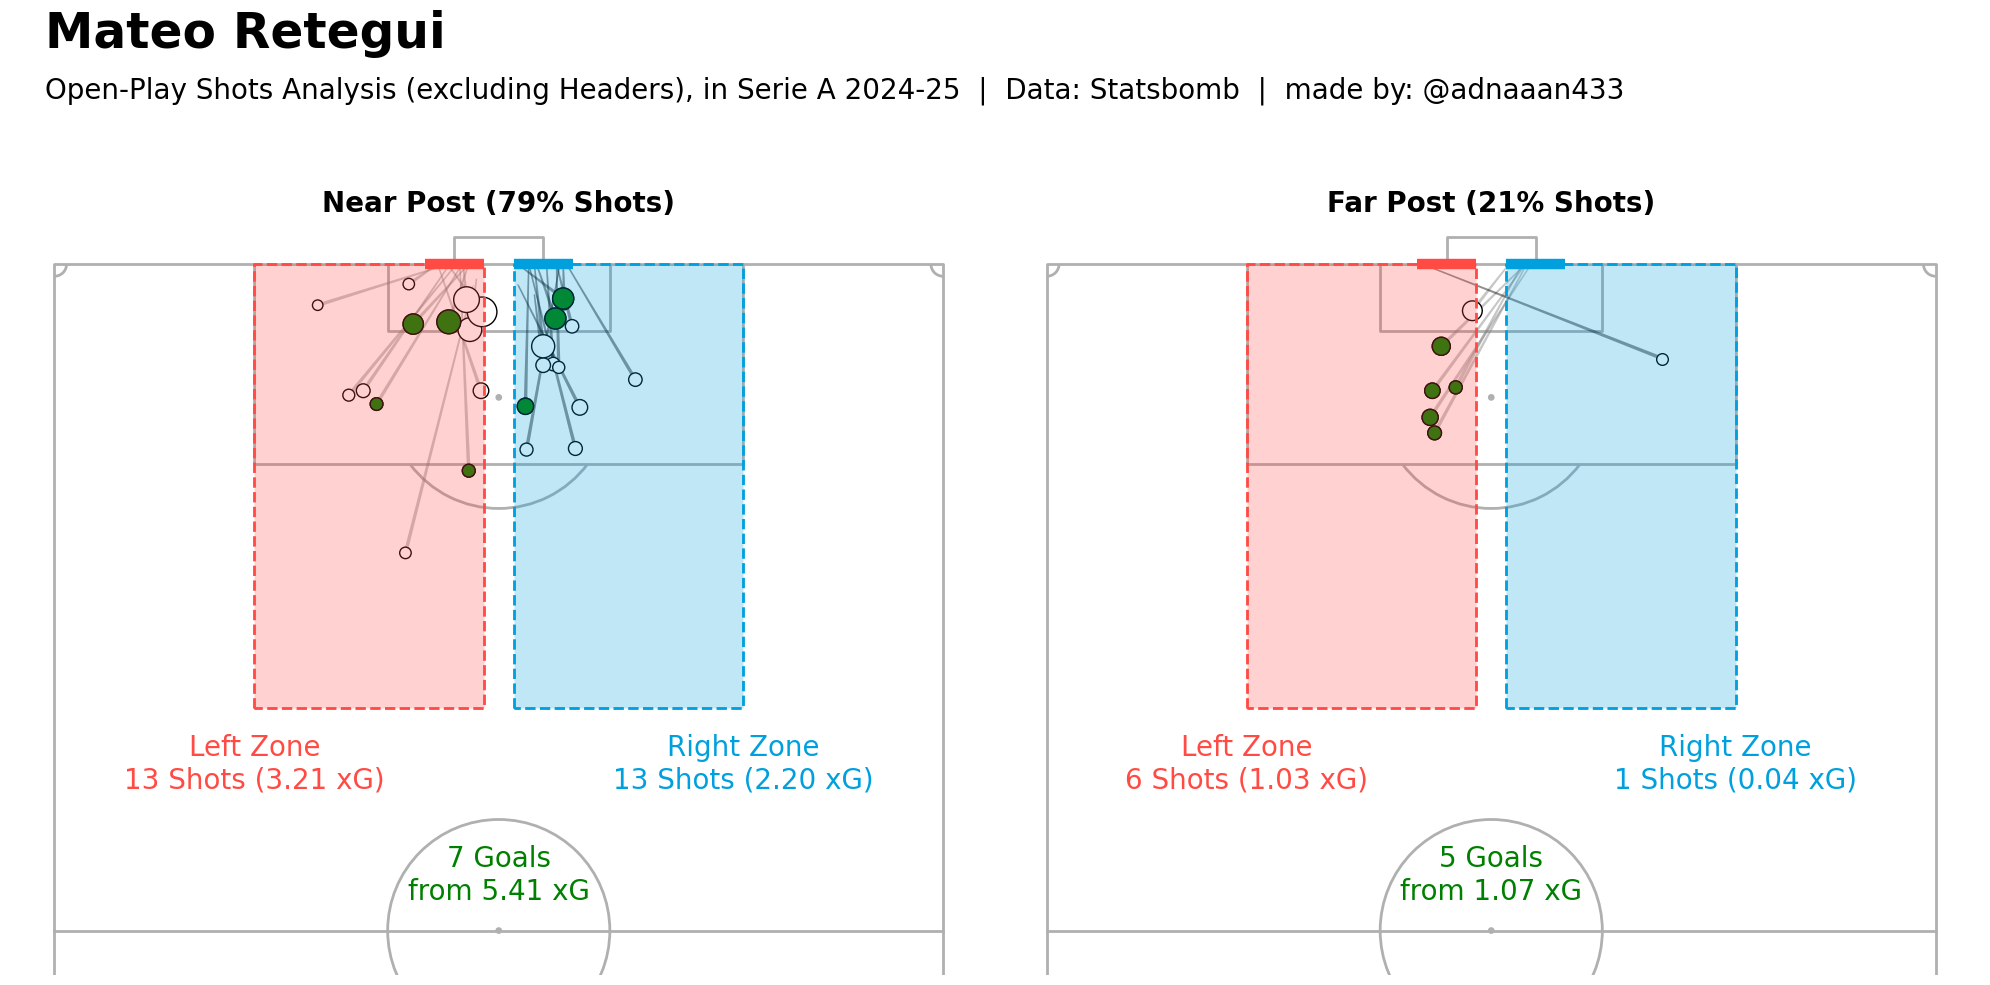

In [7]:
pname = 'Mateo Retegui'
df = dfs
total_np, total_fp = calculation(df, pname)
np_pc = round((total_np/(total_np+total_fp))*100)
fp_pc = round((total_fp/(total_np+total_fp))*100)
fig, axs = plt.subplots(1,2, figsize=(20,10))
near_post(df, axs[0], pname)
far_post(df, axs[1], pname)

fig.text(0.025, 1.05, pname, fontsize=35, fontweight='bold')
fig.text(0.025, 1, 'Open-Play Shots Analysis (excluding Headers), in Serie A 2024-25  |  Data: Statsbomb  |  made by: @adnaaan433', fontsize=20)
# fig.text(0.025, 1.02, '', fontsize=20)

plt.tight_layout()


--- Dictionary (Programmatic - basic attributes) ---
{'arc': 53.05, 'aspect': 1.0, 'aspect_equal': True, 'bottom': 80.0, 'center_length': 60.0, 'center_width': 40.0, 'circle_diameter': 20.0, 'corner_diameter': 2.186, 'goal_bottom': 44.0, 'goal_length': 2.4, 'goal_top': 36.0, 'goal_width': 8.0, 'invert_y': True, 'left': 0.0, 'length': 120.0, 'origin_center': False, 'pad_default': 4, 'pad_multiplier': 1, 'penalty_area_bottom': 62.0, 'penalty_area_left': 18.0, 'penalty_area_length': 18.0, 'penalty_area_right': 102.0, 'penalty_area_top': 18.0, 'penalty_area_width': 44.0, 'penalty_left': 12.0, 'penalty_right': 108.0, 'penalty_spot_distance': 12.0, 'pitch_length': 120.0, 'pitch_width': 80.0, 'right': 120.0, 'six_yard_bottom': 50.0, 'six_yard_left': 6.0, 'six_yard_length': 6.0, 'six_yard_right': 114.0, 'six_yard_top': 30.0, 'six_yard_width': 20.0, 'top': 0.0, 'width': 80.0}


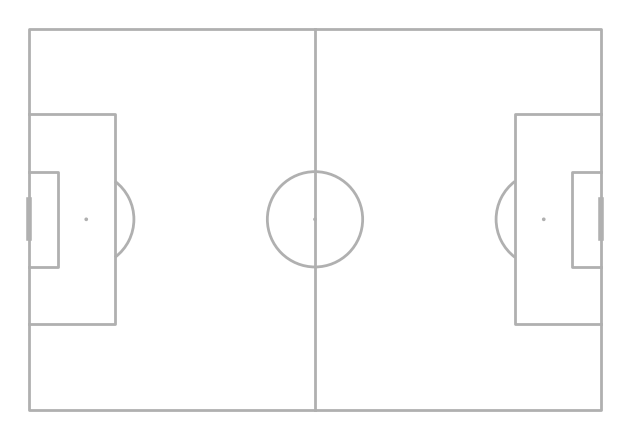

In [22]:
# Create the pitch
pitch = Pitch()
fig, ax = pitch.draw()

# Get pitch dimensions
dims = pitch.dim

# Option 2: Programmatically create a dictionary (more comprehensive)
# This iterates through all direct attributes of the FixedDims object
all_dims_dict = {}
for attr_name in dir(dims):
    if not attr_name.startswith('_') and not callable(getattr(dims, attr_name)):
        # Handle complex nested objects like 'formations' or 'position_line4'
        # These would require additional nested loops or recursive functions
        # to fully convert all their internal Coordinate/Position objects.
        # For simplicity, this example just takes direct attributes.
        attr_value = getattr(dims, attr_name)
        if isinstance(attr_value, (float, int, str, bool)): # Only include basic types for direct conversion
             all_dims_dict[attr_name] = attr_value

print("\n--- Dictionary (Programmatic - basic attributes) ---")
print(all_dims_dict)

# Chart

In [5]:
def calculation_df(df, pname):
    pitch = VerticalPitch(half=True, corner_arcs=True, goal_type='box')
    
    dims = pitch.dim

    goal_line = dims.length
    left_zone_x_start = dims.penalty_area_top
    left_zone_x_end = (dims.goal_top + (dims.goal_width)/3)
    right_zone_x_end = dims.penalty_area_bottom
    right_zone_x_start = (dims.goal_bottom - (dims.goal_width)/3)
    left_near_post_x_start = (dims.goal_top - (dims.goal_width)/3)
    left_near_post_x_end = (dims.goal_top + (dims.goal_width)/3)
    right_near_post_x_start = (dims.goal_bottom - (dims.goal_width)/3)
    right_near_post_x_end = (dims.goal_bottom + (dims.goal_width)/3)
    # near post shots
    # right zone
    l_np_shots = df[(df['player_known_name']==pname) & (df['event_type_name']=='Shot') & (df['outcome_name']!='Blocked') & 
                    (df['type_name']=='Open Play') & (df['body_part_name']!='Head') & (df['body_part_name']!='Other') &
                    (df['location_y']>left_zone_x_start) & (df['location_y']<left_zone_x_end) &
                    (df['end_location_y']>left_near_post_x_start) & (df['end_location_y']<left_near_post_x_end) & 
                    (df['end_location_x']>117) & (df['location_x']>80)].drop_duplicates(subset=['id'], keep='first')

    # left zone
    r_np_shots = df[(df['player_known_name']==pname) & (df['event_type_name']=='Shot') & (df['outcome_name']!='Blocked') & 
                    (df['type_name']=='Open Play') & (df['body_part_name']!='Head') & (df['body_part_name']!='Other') &
                    (df['location_y']>right_zone_x_start) & (df['location_y']<right_zone_x_end) &
                    (df['end_location_y']>right_near_post_x_start) & (df['end_location_y']<right_near_post_x_end) & 
                    (df['end_location_x']>117) & (df['location_x']>80)].drop_duplicates(subset=['id'], keep='first')

    np_shots = pd.concat([l_np_shots, r_np_shots])

    # far post shots
    # right zone
    l_fp_shots = df[(df['player_known_name']==pname) & (df['event_type_name']=='Shot') & (df['outcome_name']!='Blocked') & 
                    (df['type_name']=='Open Play') & (df['body_part_name']!='Head') & (df['body_part_name']!='Other') &
                    (df['location_y']>left_zone_x_start) & (df['location_y']<left_zone_x_end) &
                    (df['end_location_y']>right_near_post_x_start) & (df['end_location_y']<right_near_post_x_end) & 
                    (df['end_location_x']>117) & (df['location_x']>80)].drop_duplicates(subset=['id'], keep='first')

    # left zone
    r_fp_shots = df[(df['player_known_name']==pname) & (df['event_type_name']=='Shot') & (df['outcome_name']!='Blocked') & 
                    (df['type_name']=='Open Play') & (df['body_part_name']!='Head') & (df['body_part_name']!='Other') &
                    (df['location_y']>right_zone_x_start) & (df['location_y']<right_zone_x_end) &
                    (df['end_location_y']>left_near_post_x_start) & (df['end_location_y']<left_near_post_x_end) & 
                    (df['end_location_x']>117) & (df['location_x']>80)].drop_duplicates(subset=['id'], keep='first')

    fp_shots = pd.concat([l_fp_shots, r_fp_shots])

    total_np = len(np_shots)
    total_fp = len(fp_shots)

    np_xg = np_shots['statsbomb_xg'].sum().round(2)
    fp_xg = fp_shots['statsbomb_xg'].sum().round(2)

    np_goals = np_shots[np_shots['outcome_name']=='Goal']
    fp_goals = fp_shots[fp_shots['outcome_name']=='Goal']
    
    return {
        'Name': pname,
        'Near_Post_Shots': total_np,
        'Far_Post_Shots': total_fp,
        'Near_Post_xG': np_xg,
        'Near_Post_Goals': len(np_goals),
        'Far_Post_xG': fp_xg,
        'Far_Post_Goals': len(fp_goals),
        'Total_xG': np_xg + fp_xg,
        'Total_Goals': len(np_goals) + len(fp_goals)
        }

In [6]:
df = dfe
dfp = df[df['player_position_name'].isin(['Left Center Forward', 'Center Forward', 'Right Center Forward',
                                          'Left Attacking Midfield', 'Center Attacking Midfield', 'Right Attacking Midfield',
                                          'Left Wing', 'Right Wing'
                                         ])]
pnames = dfp['player_known_name'].unique()

results = []

for pname in pnames:
    try:
        result = calculation_df(dfp, pname)
        results.append(result)
    except Exception as e:
        print(f"Error processing {pname}: {e}")

# Create DataFrame from the list of dictionaries
npfp_df = pd.DataFrame(results)
npfp_df = npfp_df.sort_values(by='Total_Goals', ascending=False)
npfp_df

,Name,Near_Post_Shots,Far_Post_Shots,Near_Post_xG,Near_Post_Goals,Far_Post_xG,Far_Post_Goals,Total_xG,Total_Goals
71,Mohamed Salah,29,23,3.48,6,3.25,9,6.73,15
78,Bryan Mbeumo,15,11,1.32,2,1.54,8,2.86,10
87,Erling Haaland,23,7,3.90,6,1.73,4,5.63,10
34,Alexander Isak,17,10,1.56,3,2.15,5,3.71,8
31,Matheus Cunha,18,15,1.56,2,1.14,6,2.70,8
26,Jørgen Strand Larsen,15,6,2.87,4,0.91,3,3.78,7
82,Jean-Philippe Mateta,11,6,2.99,4,1.78,3,4.77,7
90,Nicolas Jackson,27,8,4.72,5,1.44,2,6.16,7
39,Harvey Barnes,13,8,2.14,2,0.76,5,2.90,7
43,Antoine Semenyo,21,14,1.48,3,0.98,4,2.46,7


In [8]:
npfp_df['Near_Post_pct'] = round((npfp_df['Near_Post_Shots']/(npfp_df['Near_Post_Shots']+npfp_df['Far_Post_Shots']))*100)
npfp_df['Far_Post_pct'] = round((npfp_df['Far_Post_Shots']/(npfp_df['Near_Post_Shots']+npfp_df['Far_Post_Shots']))*100)

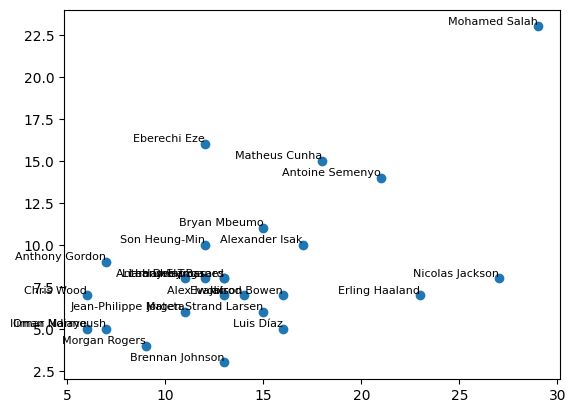

In [15]:
fig, ax = plt.subplots()

# Get the head(50) once for efficiency and clarity
df_head = npfp_df.head(25)

# Scatter plot
ax.scatter(df_head.Near_Post_Shots, df_head.Far_Post_Shots)

# Label each point with ax.text
for i, row in df_head.iterrows():
    ax.text(row.Near_Post_Shots, row.Far_Post_Shots, row.Name, fontsize=8, ha='right', va='bottom')

plt.show()